### Pytorch学习备份

>大部分的学习资料内容或者教程都可以从菜鸟教程以及B站上面找到
同时最好的学习方式就是记录+实践

Pytorch下载链接
https://pytorch.org/get-started/locally/

PyTorch 基础：
https://www.runoob.com/pytorch/pytorch-basic.html

PyTorch 张量（Tensor）
https://www.runoob.com/pytorch/pytorch-tensor.html

PyTorch 神经网络基础
https://www.runoob.com/pytorch/pytorch-neural-network.html

Pytorch torch
https://www.runoob.com/pytorch/pytorch-torch-ref.html

Transformer 模型
https://www.runoob.com/pytorch/transformer-model.html

PyTorch torch.nn 参考手册：
https://www.runoob.com/pytorch/pytorch-torch-nn-ref.html



### 环境安装验证补充


关于具体的全连接神经网络、卷积神经网络、循环神经网络、Transformer 等架构
详细可以去看菜鸟教程中Pytorch的教程部分

安装步骤命令（需要首先安装Anaconda环境）
- 可以直接使用这条命令，也可以对my_env和python版本的部分进行更改

    >conda create -n my_env python=3.11

- 激活环境，如果更改了环境名my_env也需要更改

    >conda activate my_env

- python永久更换清华园

    >pip config set global.index-url https://pypi.tuna.tsinghua.edu.cn/simple

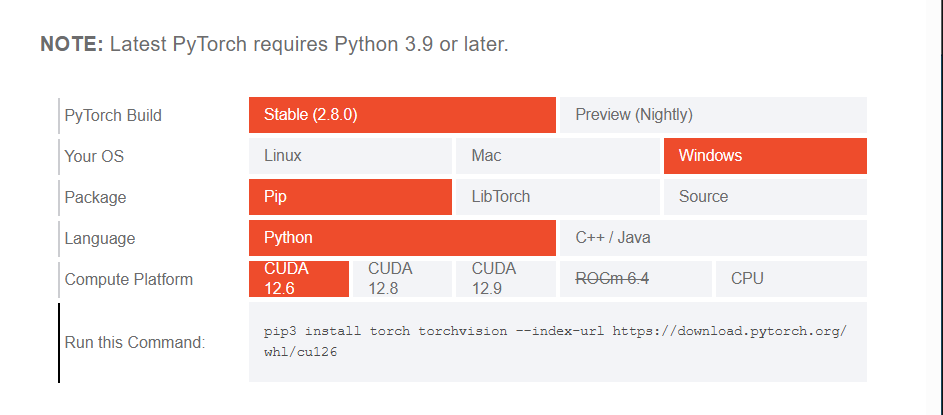
- 下载torch：https://pytorch.org/get-started/locally/

    如果有GPU可以选择

    >pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

    只有CPU

    >pip3 install torch torchvision

安装好环境之后进行检测运行

```python
import torch
import torchvision

print(f"PyTorch 版本: {torch.__version__}")
print(f"TorchVision 版本: {torchvision.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")

# 如果有 GPU，显示 GPU 信息
if torch.cuda.is_available():
    print(f"GPU 名称: {torch.cuda.get_device_name(0)}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
```


### 关于Pytorch

PyTorch 并非由 NVIDIA 公司开发，而是由 Facebook 人工智能研究院（FAIR） 团队主导开发的开源深度学习框架。其历史渊源可以追溯到更早的科学计算框架：
    




In [30]:
import torch
import numpy


In [22]:
print(torch.__version__)
print(torch.cuda.is_available())

2.8.0+cu126
True


In [ ]:
# 实现一些简单的torch矩阵
print(torch.ones(3))

tensor([1., 1., 1.])


In [23]:
W = torch.tensor([1,2, 3])
X = torch.tensor((1,2, 3))
Y = torch.tensor(numpy.array([1,2,3]))
print(W)
print(X)
print(Y)


tensor([1, 2, 3])
tensor([1, 2, 3])
tensor([1, 2, 3])


In [24]:
w = torch.empty(3, 3)

In [25]:
import torch

a = torch.zeros(2, 3)
print(a)

b = torch.ones(2, 3)
print(b)

c = torch.randn(2, 3)
print(c)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[ 0.3484,  3.2920, -1.1847],
        [-0.7955,  1.4865, -0.4008]])


In [26]:
# 创建一个需要计算一个梯度张量
x = torch.randn(2,2,requires_grad=True) # 生成随机整型
print(x)

# 执行某些操作
y = x + 2
z = y * y * 3
out = z.mean()

out

tensor([[-0.3951,  1.4267],
        [-0.6160, -1.4242]], requires_grad=True)


tensor(12.4237, grad_fn=<MeanBackward0>)

In [27]:
# 反向传播，计算梯度
out.backward() # 反向传播（Backpropagation） // 一旦定义了计算图，可以通过 .backward() 方法来计算梯度。

# 查看 x 的梯度
print(x.grad) # grad

tensor([[2.4073, 5.1400],
        [2.0760, 0.8637]])


In [28]:
# 停止梯度计算
with torch.no_grad():
    y = x * 2

神经网络（nn.Module）
神经网络是一种模仿人脑神经元连接的计算模型，由多层节点（神经元）组成，用于学习数据之间的复杂模式和关系。

神经网络通过调整神经元之间的连接权重来优化预测结果，这一过程涉及前向传播、损失计算、反向传播和参数更新。

神经网络的类型包括前馈神经网络、卷积神经网络（CNN）、循环神经网络（RNN）和长短期记忆网络（LSTM），它们在图像识别、语音处理、自然语言处理等多个领域都有广泛应用。

PyTorch 提供了一个非常方便的接口来构建神经网络模型，即 torch.nn.Module。

我们可以继承 nn.Module 类并定义自己的网络层。

创建一个简单的神经网络：

In [34]:
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的全连接神经网络
class SimpleNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super(SimpleNN, self).__init__(*args, **kwargs)
        self.fc1 = nn.Linear(2, 2) # 从输入层到输出层
        self.fc2 = nn.Linear(2, 1) # 隐藏层到输出层

    def forward(self, x):
        x = torch.relu(self.fc1(x)) # Relu 激活函数
        x = self.fc2(x)
        return x
    
# 创建网络实例
model = SimpleNN()

# 打印模型结构
print(model)


SimpleNN(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
)


训练过程：

前向传播（Forward Propagation）： 在前向传播阶段，输入数据通过网络层传递，每层应用权重和激活函数，直到产生输出。

计算损失（Calculate Loss）： 根据网络的输出和真实标签，计算损失函数的值。

反向传播（Backpropagation）： 反向传播利用自动求导技术计算损失函数关于每个参数的梯度。

参数更新（Parameter Update）： 使用优化器根据梯度更新网络的权重和偏置。

迭代（Iteration）： 重复上述过程，直到模型在训练数据上的性能达到满意的水平。

前向传播与损失计算

In [113]:
# 随机输入
x = torch.rand(1, 2) # 生成两个随机小于1的数

# 前向传播
output = model(x)
print(x)

# 定义损失函数（例如均方误差 MSE）
criterion = nn.MSELoss()
print(criterion)

# 假设目标值为1
target = torch.randn(1, 1) # 返回一个从标准正态分布填充的张量。

print(target)

tensor([[0.7820, 0.4738]])
MSELoss()
tensor([[-0.6140]])
